# 🧠 GenAI Course — Module 2
# MCP Architecture & Core Concepts

> **Spec version:** 2025-06-18 (latest)  |  **Compiled:** March 2026  
> **Library used:** `fastmcp` (v2+) — powers 70% of all MCP servers across all languages

---

## 🎯 Learning Objectives

By the end of this notebook you will be able to:

1. Draw and explain the **Host → Client → Server** architecture
2. Understand the **4-phase MCP session lifecycle**
3. Choose between **stdio** and **Streamable HTTP** transports
4. Define and implement all **4 MCP Primitives** in Python (Tools, Resources, Prompts, Sampling)
5. Apply **context window management** strategies in real code

---

## 📦 Prerequisites

```bash
pip install fastmcp          # FastMCP 2.x (recommended)
pip install mcp              # Official MCP Python SDK (also installs FastMCP 1.x)
```

All code cells in this notebook are **self-contained and runnable**. Cells marked with `🖥️ RUN` can be executed directly. Cells marked with `📖 CONCEPT` contain theory and architecture diagrams.

## 📚 Table of Contents

1. [MCP Architecture Overview — Hosts, Clients, Servers](#section-1)
2. [The Client-Server Communication Model](#section-2)
3. [Transport Layers — stdio & Streamable HTTP](#section-3)
4. [MCP Primitives](#section-4)
   - 4.1 [Tools — Functions the Model Can Invoke](#tools)
   - 4.2 [Resources — Data the Model Can Read](#resources)
   - 4.3 [Prompts — Reusable Prompt Templates](#prompts)
   - 4.4 [Sampling — Servers Request LLM Completions](#sampling)
5. [Context Window Management in MCP](#section-5)
6. [Putting It All Together — Complete Invoice MCP Server](#section-6)

In [18]:
# RUN THIS FIRST — Install dependencies
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('fastmcp')
install('mcp')

print('Dependencies installed successfully!\n')

# Verify versions
from importlib.metadata import version

print("fastmcp version :", version("fastmcp"))
print("mcp version     :", version("mcp"))

Dependencies installed successfully!

fastmcp version : 3.1.0
mcp version     : 1.26.0


---
# 1. MCP Architecture Overview — Hosts, Clients & Servers

## 📖 CONCEPT: The Three-Layer Architecture

MCP uses a **3-layer modular architecture**. Every component has a single, clearly defined responsibility:

```
┌─────────────────────────────────────────────────────────┐
│                        USER                             │
└───────────────────────────┬─────────────────────────────┘
                            │
┌───────────────────────────▼─────────────────────────────┐
│                     🏠  MCP HOST                        │
│         (Claude Desktop / Cursor / VS Code / Agent)     │
│  • Contains the LLM          • Enforces security        │
│  • Manages user consent      • Controls context window  │
└──────┬──────────────────────────────────────┬───────────┘
       │  1:1 per server                      │  1:1 per server
┌──────▼──────┐                        ┌──────▼──────┐
│ 🔌 CLIENT 1 │                        │ 🔌 CLIENT 2 │
│  Protocol   │                        │  Protocol   │
│  Handler    │                        │  Handler    │
└──────┬──────┘                        └──────┬──────┘
       │  JSON-RPC 2.0                        │  JSON-RPC 2.0
       │  (stdio or Streamable HTTP)          │
┌──────▼──────┐                        ┌──────▼──────┐
│ 🛠️ SERVER 1 │                        │ 🛠️ SERVER 2 │
│   GitHub    │                        │ PostgreSQL  │
└─────────────┘                        └─────────────┘
```

### The Three Components:

| Component | Role | Examples |
|-----------|------|----------|
| **Host** | Orchestrates everything, contains the LLM | Claude Desktop, Cursor, VS Code, Windsurf |
| **Client** | 1:1 protocol handler per server | Built into the Host application |
| **Server** | Exposes tools, resources, prompts | GitHub, Slack, PostgreSQL, custom servers |

### 🔐 Key Security Property
> **Servers are isolated from each other.** A compromised GitHub MCP server **cannot** access your PostgreSQL MCP server. The host enforces this boundary.

In [22]:
# CONCEPT: Visualising the architecture in Python
# This cell demonstrates the conceptual relationship between components

class MCPServer:
    """Represents an MCP Server — exposes tools, resources, prompts"""
    def __init__(self, name: str, capabilities: list):
        self.name = name
        self.capabilities = capabilities
    
    def __repr__(self):
        return f"MCPServer('{self.name}', capabilities={self.capabilities})"


class MCPClient:
    """Represents an MCP Client — 1:1 with one server"""
    def __init__(self, server: MCPServer):
        self.server = server
        self.session_active = False
    
    def connect(self):
        self.session_active = True
        print(f"   Client connected to → {self.server.name}")
        print(f"     Discovered capabilities: {self.server.capabilities}")


class MCPHost:
    """Represents an MCP Host — orchestrates all clients, contains LLM"""
    def __init__(self, name: str):
        self.name = name
        self.clients: list[MCPClient] = []
    
    def add_server(self, server: MCPServer):
        """Host creates a new client for each server it connects to"""
        client = MCPClient(server)          # One client per server
        client.connect()
        self.clients.append(client)
    
    def list_all_capabilities(self):
        """Host aggregates capabilities from ALL connected servers"""
        print(f"\n {self.name} — All available capabilities:")
        for client in self.clients:
            print(f"   [{client.server.name}]: {client.server.capabilities}")


# ── Simulate the architecture ──────────────────────────────────────────────
print("=" * 60)
print("Simulating MCP Architecture")
print("=" * 60)

# Define servers
github_server   = MCPServer("GitHub MCP",     ["list_issues", "create_pr", "search_code"])
postgres_server = MCPServer("PostgreSQL MCP", ["query_db", "list_tables", "describe_schema"])
drive_server    = MCPServer("Google Drive MCP",["list_files", "read_file", "search_docs"])

# Host creates a client for each server — isolation enforced
print("\nHost connecting to servers...")
host = MCPHost("Claude Desktop")
host.add_server(github_server)
host.add_server(postgres_server)
host.add_server(drive_server)

# Host sees aggregated capabilities from all servers
host.list_all_capabilities()

print(f"\n Total clients managed by host: {len(host.clients)}")
print(f"\n Servers are isolated — GitHub server CANNOT access PostgreSQL server")

Simulating MCP Architecture

Host connecting to servers...
   Client connected to → GitHub MCP
     Discovered capabilities: ['list_issues', 'create_pr', 'search_code']
   Client connected to → PostgreSQL MCP
     Discovered capabilities: ['query_db', 'list_tables', 'describe_schema']
   Client connected to → Google Drive MCP
     Discovered capabilities: ['list_files', 'read_file', 'search_docs']

 Claude Desktop — All available capabilities:
   [GitHub MCP]: ['list_issues', 'create_pr', 'search_code']
   [PostgreSQL MCP]: ['query_db', 'list_tables', 'describe_schema']
   [Google Drive MCP]: ['list_files', 'read_file', 'search_docs']

 Total clients managed by host: 3

 Servers are isolated — GitHub server CANNOT access PostgreSQL server


In [56]:
from fastmcp import FastMCP, Client

# 1) Create a real MCP server
mcp = FastMCP("SimpleInvoiceServer")

# 2) Expose real tools
@mcp.tool
def add_numbers(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

@mcp.tool
def extract_invoice_total(subtotal: float, gst_percent: float) -> dict:
    """Return GST amount and grand total."""
    gst_amount = round(subtotal * gst_percent / 100, 2)
    grand_total = round(subtotal + gst_amount, 2)
    return {
        "subtotal": subtotal,
        "gst_percent": gst_percent,
        "gst_amount": gst_amount,
        "grand_total": grand_total
    }

# 3) Create a real MCP client connected to that server
client = Client(mcp)

# 4) Call tools through MCP
async with client:
    tools = await client.list_tools()
    print("Available tools:")
    for t in tools:
        print("-", t.name)

    result1 = await client.call_tool("add_numbers", {"a": 15750, "b": 2835})
    print("\nadd_numbers result:")
    print(result1.data)

    result2 = await client.call_tool(
        "extract_invoice_total",
        {"subtotal": 15750, "gst_percent": 18}
    )
    print("\nextract_invoice_total result:")
    print(result2.data)

Available tools:
- add_numbers
- extract_invoice_total

add_numbers result:
18585.0

extract_invoice_total result:
{'subtotal': 15750.0, 'gst_percent': 18.0, 'gst_amount': 2835.0, 'grand_total': 18585.0}


---
# 2. The Client-Server Communication Model

## 📖 CONCEPT: JSON-RPC 2.0

All MCP communication uses **JSON-RPC 2.0** — a lightweight remote procedure call protocol. Every message is UTF-8 JSON.

### Three Message Types:

| Type | Has ID? | Direction | Purpose |
|------|---------|-----------|--------|
| **Request** | Yes | Either direction | Ask for action; expects Response |
| **Response** | Yes (matches Request) | Opposite of Request | Returns result or error |
| **Notification** | No | Either direction | Fire-and-forget (e.g. progress) |

## 📖 CONCEPT: The 4-Phase Session Lifecycle

```
CLIENT                              SERVER
  │                                    │
  │──── initialize (version, caps) ───▶│  Phase 1: INITIALIZE
  │◀─── result (server caps)  ─────────│  (Capability Handshake)
  │──── initialized (notification) ───▶│
  │                                    │
  │──── tools/list ────────────────────▶│  Phase 2: DISCOVER
  │◀─── result ([tool1, tool2, ...]) ───│  (List capabilities)
  │──── resources/list ────────────────▶│
  │◀─── result ([res1, res2, ...]) ─────│
  │                                    │
  │──── tools/call {name, args} ───────▶│  Phase 3: OPERATE
  │◀─── result {content} ──────────────│  (Invoke tools/read resources)
  │◀─── sampling/createMessage ─────────│  (Server → Client sampling)
  │──── result {completion} ──────────▶│
  │                                    │
  │──── [disconnect] ──────────────────▶│  Phase 4: TERMINATE
  │                                    │
```

In [24]:
# 📖 CONCEPT: JSON-RPC 2.0 message structure
import json

def pretty(d: dict) -> str:
    return json.dumps(d, indent=2)

# ── Phase 1: Initialize ────────────────────────────────────────────────────
initialize_request = {
    "jsonrpc": "2.0",
    "id": 1,
    "method": "initialize",
    "params": {
        "protocolVersion": "2025-06-18",          # Latest spec version
        "capabilities": {
            "elicitation": {},                     # Client supports elicitation
            "sampling":    {}                      # Client supports sampling
        },
        "clientInfo": {
            "name":    "claude-desktop",
            "version": "1.0.0"
        }
    }
}

server_response = {
    "jsonrpc": "2.0",
    "id": 1,
    "result": {
        "protocolVersion": "2025-06-18",
        "capabilities": {
            "tools":     {},                       # Server exposes tools
            "resources": {"subscribe": True},      # Server supports subscriptions
            "prompts":   {}
        },
        "serverInfo": {
            "name":    "invoice-mcp-server",
            "version": "1.0.0"
        }
    }
}

# ── Phase 2: Discover ──────────────────────────────────────────────────────
tools_list_request = {
    "jsonrpc": "2.0",
    "id": 2,
    "method": "tools/list"
}

tools_list_response = {
    "jsonrpc": "2.0",
    "id": 2,
    "result": {
        "tools": [
            {
                "name":        "extract_invoice",
                "description": "Extract structured data from an invoice email",
                "inputSchema": {
                    "type": "object",
                    "properties": {
                        "email_body": {"type": "string", "description": "Raw email text"},
                        "currency":   {"type": "string", "default": "INR"}
                    },
                    "required": ["email_body"]
                }
            }
        ]
    }
}

# ── Phase 3: Operate ───────────────────────────────────────────────────────
tool_call_request = {
    "jsonrpc": "2.0",
    "id": 3,
    "method": "tools/call",
    "params": {
        "name":      "extract_invoice",
        "arguments": {
            "email_body": "Invoice Number: INV-1001, Total: 18585 INR",
            "currency":   "INR"
        }
    }
}

tool_call_response = {
    "jsonrpc": "2.0",
    "id": 3,
    "result": {
        "content": [
            {
                "type": "text",
                "text": json.dumps({
                    "invoice_number": "INV-1001",
                    "total": 18585,
                    "currency": "INR"
                })
            }
        ]
    }
}

print("=" * 60)
print("PHASE 1 — Client sends: initialize")
print("=" * 60)
print(pretty(initialize_request))
print("\nServer responds:")
print(pretty(server_response))

print("\n" + "=" * 60)
print("PHASE 2 — Client sends: tools/list")
print("=" * 60)
print(pretty(tools_list_response))

print("\n" + "=" * 60)
print("PHASE 3 — Client sends: tools/call")
print("=" * 60)
print(pretty(tool_call_request))
print("\nServer responds:")
print(pretty(tool_call_response))

PHASE 1 — Client sends: initialize
{
  "jsonrpc": "2.0",
  "id": 1,
  "method": "initialize",
  "params": {
    "protocolVersion": "2025-06-18",
    "capabilities": {
      "elicitation": {},
      "sampling": {}
    },
    "clientInfo": {
      "name": "claude-desktop",
      "version": "1.0.0"
    }
  }
}

Server responds:
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "protocolVersion": "2025-06-18",
    "capabilities": {
      "tools": {},
      "resources": {
        "subscribe": true
      },
      "prompts": {}
    },
    "serverInfo": {
      "name": "invoice-mcp-server",
      "version": "1.0.0"
    }
  }
}

PHASE 2 — Client sends: tools/list
{
  "jsonrpc": "2.0",
  "id": 2,
  "result": {
    "tools": [
      {
        "name": "extract_invoice",
        "description": "Extract structured data from an invoice email",
        "inputSchema": {
          "type": "object",
          "properties": {
            "email_body": {
              "type": "string",
              "descr

---
# 3. Transport Layers — stdio & Streamable HTTP

## 📖 CONCEPT: Two Official Transports

MCP intentionally defines **only two** transport mechanisms to keep the ecosystem interoperable.

| | `stdio` | `Streamable HTTP` |
|--|---------|------------------|
| **How** | Host spawns server as subprocess; reads/writes stdin/stdout | Server runs as HTTP service on a single `/mcp` endpoint |
| **Use when** | Same machine, local dev, personal tools | Remote/cloud, multi-user, enterprise |
| **Auth** | OS process isolation | OAuth 2.1, Bearer tokens |
| **Setup** | Zero config | HTTP server + TLS |
| **Scaling** | Single machine only | Cloud-native, load-balanced |

### ⚠️ Important History
> The original `HTTP+SSE` transport (spec 2024-11-05) used **two separate endpoints** — one GET for SSE streaming and one POST for messages. This was **deprecated in March 2025** (spec 2025-03-26) and replaced by **Streamable HTTP** which uses a single endpoint. If you see code using `mcp.run(transport='sse')`, it is using the old deprecated transport.

### 🔑 One-Sentence Decision Rule
> If the person using the AI client **also controls the machine** the server runs on → use **stdio**.  
> If they don't → use **Streamable HTTP**.

In [26]:
# 📖 CONCEPT: Transport configuration comparison
# This cell shows the code difference between stdio and Streamable HTTP
# NOTE: Don't run the mcp.run() lines here — they start blocking servers
#       They are shown for reference only

from fastmcp import FastMCP

# ── Option A: stdio Transport ──────────────────────────────────────────────
stdio_server_code = '''
from fastmcp import FastMCP

mcp = FastMCP("My Local Server")

@mcp.tool()
def greet(name: str) -> str:
    """Say hello to someone."""
    return f"Hello, {name}!"

if __name__ == "__main__":
    mcp.run(transport="stdio")   # ← Default transport, local only
    # Claude Desktop config (claude_desktop_config.json):
    # { "mcpServers": { "my-server": {
    #     "command": "python",
    #     "args": ["/path/to/server.py"] }}}
'''

# ── Option B: Streamable HTTP Transport ───────────────────────────────────
http_server_code = '''
from fastmcp import FastMCP

mcp = FastMCP("My Remote Server")

@mcp.tool()
def greet(name: str) -> str:
    """Say hello to someone."""
    return f"Hello, {name}!"

if __name__ == "__main__":
    mcp.run(
        transport="streamable-http",  # ← Remote transport
        host="0.0.0.0",               # ← Listen on all interfaces
        port=8000,                    # ← Accessible at http://host:8000/mcp
    )
    # Client connects to: http://your-server.com:8000/mcp
    # Supports: OAuth 2.1, load balancers, multi-user sessions
'''

# ── Deprecated: Old SSE Transport (DO NOT USE) ─────────────────────────────
deprecated_sse_code = '''
# ❌ DEPRECATED — SSE Transport (spec 2024-11-05, removed in 2025-03-26)
# Had TWO separate endpoints:
#   GET  /sse   → for receiving server events
#   POST /message → for sending client requests
# Problems: incompatible with load balancers, no auth on GET, corporate firewalls

mcp.run(transport="sse")   # ← Old way, now deprecated
'''

print("=" * 60)
print("Transport Option A: stdio (local, zero-config)")
print("=" * 60)
print(stdio_server_code)

print("=" * 60)
print("Transport Option B: Streamable HTTP (remote, cloud-native)")
print("=" * 60)
print(http_server_code)

print("=" * 60)
print("⚠️  Deprecated: SSE Transport — DO NOT USE IN NEW PROJECTS")
print("=" * 60)
print(deprecated_sse_code)

Transport Option A: stdio (local, zero-config)

from fastmcp import FastMCP

mcp = FastMCP("My Local Server")

@mcp.tool()
def greet(name: str) -> str:
    """Say hello to someone."""
    return f"Hello, {name}!"

if __name__ == "__main__":
    mcp.run(transport="stdio")   # ← Default transport, local only
    # Claude Desktop config (claude_desktop_config.json):
    # { "mcpServers": { "my-server": {
    #     "command": "python",
    #     "args": ["/path/to/server.py"] }}}

Transport Option B: Streamable HTTP (remote, cloud-native)

from fastmcp import FastMCP

mcp = FastMCP("My Remote Server")

@mcp.tool()
def greet(name: str) -> str:
    """Say hello to someone."""
    return f"Hello, {name}!"

if __name__ == "__main__":
    mcp.run(
        transport="streamable-http",  # ← Remote transport
        host="0.0.0.0",               # ← Listen on all interfaces
        port=8000,                    # ← Accessible at http://host:8000/mcp
    )
    # Client connects to: http://your-serv

In [28]:
# 🖥️ RUN: Create a minimal FastMCP server object and inspect it
from fastmcp import FastMCP

# Instantiate a server — this does NOT start any transport yet
mcp = FastMCP(
    name="Demo Server",
    instructions="A demonstration MCP server for the GenAI course."
)

print(f"Server name        : {mcp.name}")
print(f"Instructions       : {mcp.instructions}")
print()
print("To run with stdio transport:")
print("  mcp.run(transport='stdio')")
print()
print("To run with Streamable HTTP transport:")
print("  mcp.run(transport='streamable-http', host='0.0.0.0', port=8000)")
print()
print("✅ Server object created successfully (not started)")

Server name        : Demo Server
Instructions       : A demonstration MCP server for the GenAI course.

To run with stdio transport:
  mcp.run(transport='stdio')

To run with Streamable HTTP transport:
  mcp.run(transport='streamable-http', host='0.0.0.0', port=8000)

✅ Server object created successfully (not started)


---
# 4. MCP Primitives

## 📖 CONCEPT: The Four Primitives

MCP defines **four core primitives** — the building blocks that servers expose and clients consume.

```
┌─────────────┬──────────────────────┬──────────────────┬────────────────────────────────┐
│  Primitive  │    Controller        │     Analogy      │          Purpose               │
├─────────────┼──────────────────────┼──────────────────┼────────────────────────────────┤
│ 🛠️ Tools    │ Model-controlled     │ POST endpoint    │ Execute actions & computations │
│ 📁 Resources│ Application-controlled│ GET endpoint    │ Read data into context         │
│ 📝 Prompts  │ User-controlled      │ Slash commands   │ Reusable prompt templates      │
│ 🔄 Sampling │ Server-initiated     │ Reverse API call │ Server requests LLM completion │
└─────────────┴──────────────────────┴──────────────────┴────────────────────────────────┘
```

> **Who controls it?** This is the most important distinction to understand.

---
## 4.1 🛠️ Tools — Functions the Model Can Invoke

### 📖 CONCEPT

**Tools** are executable functions that the **LLM autonomously decides to call** when needed to fulfil a user request. They are the most commonly used MCP primitive.

- Think of tools as **POST endpoints** — they perform actions and have side effects
- The model reads the tool's `name`, `description`, and `inputSchema` (JSON Schema) to know when and how to call it
- The **host must get user consent** before any tool is executed
- As of spec **2025-06-18**, tools can declare **output schemas** to describe their return structure

### Tool Invocation Flow:
```
User Request
    ↓
LLM selects tool based on description + input schema
    ↓
Host shows consent dialog: "Allow Claude to call extract_invoice?"
    ↓
Client sends tools/call → Server executes function
    ↓
Result returned → Added to LLM context → LLM responds
```

In [30]:
# RUN: Defining Tools with FastMCP
from fastmcp import FastMCP
from typing import Optional
import json

mcp = FastMCP("Invoice Server")

# ── Tool 1: Simple synchronous tool ───────────────────────────────────────
@mcp.tool()
def add_numbers(a: float, b: float) -> float:
    """
    Add two numbers together.
    
    Args:
        a: First number
        b: Second number
    
    Returns:
        Sum of a and b
    """
    return a + b


# ── Tool 2: Tool with optional parameters and type hints ──────────────────
@mcp.tool()
def extract_invoice_data(
    email_body: str,
    currency: str = "INR",
    strict_mode: bool = False
) -> dict:
    """
    Extract structured invoice data from a raw email body.
    
    Parses invoice details including line items, totals, GST,
    vendor information, and payment due dates.
    
    Args:
        email_body:  The full text content of the invoice email
        currency:    Currency code to normalise all amounts (default: INR)
        strict_mode: If True, raises error on missing required fields
    
    Returns:
        Dictionary with invoice_number, vendor_name, items, totals, due_date
    """
    # 🔍 FastMCP auto-generates JSON Schema from type hints + docstring!
    # In production, use regex/NLP/LLM to parse the email
    
    import re
    
    result = {"currency": currency, "raw_length": len(email_body)}
    
    # Simple pattern matching for demonstration
    inv_match = re.search(r'Invoice Number\s*[:\-]?\s*(INV-\w+)', email_body, re.IGNORECASE)
    if inv_match:
        result["invoice_number"] = inv_match.group(1)
    
    total_match = re.search(r'Total Invoice Amount\s*[:\-]?\s*([\d,]+)', email_body, re.IGNORECASE)
    if total_match:
        result["total_amount"] = float(total_match.group(1).replace(',', ''))
    
    vendor_match = re.search(r'Vendor Name\s*[:\-]?\s*(.+)', email_body, re.IGNORECASE)
    if vendor_match:
        result["vendor_name"] = vendor_match.group(1).strip()
    
    if strict_mode and "invoice_number" not in result:
        raise ValueError("Invoice number not found in email body")
    
    return result


# ── Tool 3: Async tool ────────────────────────────────────────────────────
@mcp.tool()
async def validate_gst(
    subtotal: float,
    gst_percentage: float,
    claimed_gst_amount: float
) -> dict:
    """
    Validate GST calculation in an invoice.
    
    Args:
        subtotal:           Invoice subtotal before GST
        gst_percentage:     GST rate applied (e.g. 18 for 18%)
        claimed_gst_amount: GST amount stated in the invoice
    
    Returns:
        Validation result with expected vs actual amounts
    """
    expected_gst = round(subtotal * gst_percentage / 100, 2)
    is_valid     = abs(expected_gst - claimed_gst_amount) < 0.01  # 1 paisa tolerance
    
    return {
        "is_valid":         is_valid,
        "expected_gst":     expected_gst,
        "claimed_gst":      claimed_gst_amount,
        "difference":       round(expected_gst - claimed_gst_amount, 2),
        "expected_total":   round(subtotal + expected_gst, 2)
    }


print(" Tools registered successfully!")
print()
print("Registered tools:")
for tool_name in ["add_numbers", "extract_invoice_data", "validate_gst"]:
    print(f"   {tool_name}")

 Tools registered successfully!

Registered tools:
   add_numbers
   extract_invoice_data
   validate_gst


In [34]:
sample_email = """
Invoice Details
---------------
Invoice Number : INV-1001
Invoice Date   : 05-Mar-2026
Vendor Name    : Alpha Electronics Pvt Ltd

Item Details
------------
1. Laptop Charger    Qty: 10   Unit Price: 1200   Total: 12000
2. USB Cable         Qty: 25   Unit Price: 150    Total: 3750

Subtotal                  : 15750
GST (18%)                 : 2835
Total Invoice Amount      : 18585

Payment Due Date          : 20-Mar-2026
"""

import json

# Test Tool 1
print("=" * 55)
print("🛠️  Tool: add_numbers")
print("=" * 55)
result = add_numbers(15750, 2835)
print(f"add_numbers(15750, 2835) = {result}")

# Test Tool 2
print("\n" + "=" * 55)
print("🛠️  Tool: extract_invoice_data")
print("=" * 55)
extracted = extract_invoice_data(sample_email, currency="INR")
print(json.dumps(extracted, indent=2))

# Test Tool 3 (Jupyter async style)
print("\n" + "=" * 55)
print("🛠️  Tool: validate_gst")
print("=" * 55)

validation = await validate_gst(
    subtotal=15750,
    gst_percentage=18,
    claimed_gst_amount=2835
)

print(json.dumps(validation, indent=2))
print()

if validation["is_valid"]:
    print("✅ GST calculation is CORRECT")
else:
    print(f"❌ GST mismatch! Difference: ₹{validation['difference']}")

🛠️  Tool: add_numbers
add_numbers(15750, 2835) = 18585

🛠️  Tool: extract_invoice_data
{
  "currency": "INR",
  "raw_length": 426,
  "invoice_number": "INV-1001",
  "total_amount": 18585.0,
  "vendor_name": "Alpha Electronics Pvt Ltd"
}

🛠️  Tool: validate_gst
{
  "is_valid": true,
  "expected_gst": 2835.0,
  "claimed_gst": 2835,
  "difference": 0.0,
  "expected_total": 18585.0
}

✅ GST calculation is CORRECT


In [36]:
# 📖 CONCEPT: What the LLM actually sees — the auto-generated JSON Schema
# FastMCP generates this automatically from your type hints + docstring

import json

# This is the schema that gets sent to the LLM during tools/list
auto_generated_schema = {
    "name": "extract_invoice_data",
    "description": "Extract structured invoice data from a raw email body.",
    "inputSchema": {
        "type": "object",
        "title": "extract_invoice_data",
        "properties": {
            "email_body": {
                "type": "string",
                "description": "The full text content of the invoice email"
            },
            "currency": {
                "type": "string",
                "default": "INR",
                "description": "Currency code to normalise all amounts"
            },
            "strict_mode": {
                "type": "boolean",
                "default": False,
                "description": "If True, raises error on missing required fields"
            }
        },
        "required": ["email_body"]   # Only non-default params are required
    }
}

print("📋 Auto-generated JSON Schema (sent to LLM during tools/list):")
print(json.dumps(auto_generated_schema, indent=2))
print()
print("💡 Key insight: FastMCP generates this automatically from:")
print("   • Python type hints  → inputSchema types")
print("   • Default values     → required vs optional params")
print("   • Docstring Args:    → field descriptions")
print("   • Function docstring → tool description")

📋 Auto-generated JSON Schema (sent to LLM during tools/list):
{
  "name": "extract_invoice_data",
  "description": "Extract structured invoice data from a raw email body.",
  "inputSchema": {
    "type": "object",
    "title": "extract_invoice_data",
    "properties": {
      "email_body": {
        "type": "string",
        "description": "The full text content of the invoice email"
      },
      "currency": {
        "type": "string",
        "default": "INR",
        "description": "Currency code to normalise all amounts"
      },
      "strict_mode": {
        "type": "boolean",
        "default": false,
        "description": "If True, raises error on missing required fields"
      }
    },
    "required": [
      "email_body"
    ]
  }
}

💡 Key insight: FastMCP generates this automatically from:
   • Python type hints  → inputSchema types
   • Default values     → required vs optional params
   • Docstring Args:    → field descriptions
   • Function docstring → tool description


---
## 4.2 📁 Resources — Data Files the Model Can Read

### 📖 CONCEPT

**Resources** are data sources that servers expose for clients to read and inject into the LLM's context. They are **application-controlled** — the host decides when to load them, not the model.

- Think of resources as **GET endpoints** — they read data without side effects
- Every resource has a **URI** (Uniform Resource Identifier) as its unique address
- Resources can be **static** (fixed URI, always available) or **dynamic** (URI templates with parameters)
- Resources support **real-time subscriptions** — clients can watch for changes

### Resource URI Examples:
```
file:///home/user/invoices/INV-1001.pdf
database://invoices/INV-1001
github://anthropics/claude-code/README.md
config://app/settings
memory://session/context
```

### ⚠️ Resources vs Tools — Key Distinction
> The model **cannot** autonomously read a resource. The host application must explicitly fetch it and provide it to the model. If you want the **model to pull data autonomously**, expose it as a **Tool** instead.

In [38]:
# 🖥️ RUN: Defining Resources with FastMCP
from fastmcp import FastMCP
from datetime import datetime
import json

mcp = FastMCP("Invoice Resource Server")

# ── Resource 1: Static resource — always the same URI ─────────────────────
@mcp.resource(
    uri="config://invoice-server/settings",
    description="Server configuration and supported invoice formats"
)
def get_server_config() -> dict:
    """Returns the server's static configuration."""
    return {
        "version":            "1.0.0",
        "supported_formats":  ["plain_text", "html", "pdf_text"],
        "supported_currencies": ["INR", "USD", "EUR", "GBP"],
        "default_gst_rate":   18,
        "max_line_items":     100
    }


# ── Resource 2: Dynamic resource — URI template with parameter ─────────────
# Invoice database (in-memory for demo)
INVOICE_DB = {
    "INV-1001": {
        "invoice_number": "INV-1001",
        "invoice_date":   "2026-03-05",
        "vendor_name":    "Alpha Electronics Pvt Ltd",
        "subtotal":       15750,
        "gst_amount":     2835,
        "total":          18585,
        "currency":       "INR",
        "due_date":       "2026-03-20",
        "status":         "pending"
    },
    "INV-1002": {
        "invoice_number": "INV-1002",
        "invoice_date":   "2026-03-06",
        "vendor_name":    "Tech Supplies Ltd",
        "subtotal":       8000,
        "gst_amount":     1440,
        "total":          9440,
        "currency":       "INR",
        "due_date":       "2026-03-25",
        "status":         "paid"
    }
}

@mcp.resource(
    uri="database://invoices/{invoice_id}",     # ← URI template (RFC 6570)
    description="Retrieve a specific invoice record by ID"
)
def get_invoice(invoice_id: str) -> dict:
    """Fetch a single invoice from the database by its ID."""
    if invoice_id not in INVOICE_DB:
        return {"error": f"Invoice {invoice_id} not found", "available": list(INVOICE_DB.keys())}
    return INVOICE_DB[invoice_id]


# ── Resource 3: Resource returning text (a report) ────────────────────────
@mcp.resource(
    uri="reports://invoices/pending-summary",
    description="Markdown summary of all pending invoices requiring payment"
)
def get_pending_invoices_report() -> str:
    """Generate a text report of all pending invoices."""
    pending = [inv for inv in INVOICE_DB.values() if inv["status"] == "pending"]
    
    if not pending:
        return "# Pending Invoices\n\nNo pending invoices found."
    
    lines = ["# Pending Invoices Report",
             f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             f"Total pending: {len(pending)}", ""]
    
    total_due = 0
    for inv in pending:
        lines.append(f"## {inv['invoice_number']}")
        lines.append(f"- Vendor   : {inv['vendor_name']}")
        lines.append(f"- Amount   : {inv['currency']} {inv['total']:,}")
        lines.append(f"- Due Date : {inv['due_date']}")
        lines.append("")
        total_due += inv["total"]
    
    lines.append(f"---\n**Total Outstanding: INR {total_due:,}**")
    return "\n".join(lines)


# ── Test the resources directly ────────────────────────────────────────────
print("=" * 55)
print("📁 Resource 1: config://invoice-server/settings")
print("=" * 55)
print(json.dumps(get_server_config(), indent=2))

print("\n" + "=" * 55)
print("📁 Resource 2: database://invoices/INV-1001")
print("=" * 55)
print(json.dumps(get_invoice("INV-1001"), indent=2))

print("\n" + "=" * 55)
print("📁 Resource 3: reports://invoices/pending-summary")
print("=" * 55)
print(get_pending_invoices_report())

📁 Resource 1: config://invoice-server/settings
{
  "version": "1.0.0",
  "supported_formats": [
    "plain_text",
    "html",
    "pdf_text"
  ],
  "supported_currencies": [
    "INR",
    "USD",
    "EUR",
    "GBP"
  ],
  "default_gst_rate": 18,
  "max_line_items": 100
}

📁 Resource 2: database://invoices/INV-1001
{
  "invoice_number": "INV-1001",
  "invoice_date": "2026-03-05",
  "vendor_name": "Alpha Electronics Pvt Ltd",
  "subtotal": 15750,
  "gst_amount": 2835,
  "total": 18585,
  "currency": "INR",
  "due_date": "2026-03-20",
  "status": "pending"
}

📁 Resource 3: reports://invoices/pending-summary
# Pending Invoices Report
Generated: 2026-03-11 00:27
Total pending: 1

## INV-1001
- Vendor   : Alpha Electronics Pvt Ltd
- Amount   : INR 18,585
- Due Date : 2026-03-20

---
**Total Outstanding: INR 18,585**


In [40]:
# 📖 CONCEPT: Resource Subscriptions (Real-Time Updates)
# In a real MCP session, clients can SUBSCRIBE to resource changes

subscription_flow = """
Real-Time Resource Subscription Flow
=====================================

1. Client → Server: resources/subscribe
   { "uri": "database://invoices/INV-1001" }

2. [Later, invoice status changes to 'paid' in the database]

3. Server → Client: notifications/resources/updated  (push notification!)
   { "uri": "database://invoices/INV-1001" }

4. Client → Server: resources/read  (fetch fresh content)
   { "uri": "database://invoices/INV-1001" }

5. Server → Client: result with updated invoice data

Use cases:
  • Live database record changes
  • File system changes
  • Real-time dashboard metrics
  • Stock/pricing updates
"""

print(subscription_flow)

# Simulating a server-side notification trigger
import asyncio
from fastmcp import FastMCP
from fastmcp.server.context import Context

mcp_notify = FastMCP("Notification Demo")

@mcp_notify.tool()
async def update_invoice_status(
    invoice_id: str,
    new_status: str,
    ctx: Context           # ← Context gives access to session methods
) -> str:
    """
    Update invoice payment status and notify subscribed clients.
    
    Args:
        invoice_id: Invoice ID to update (e.g. INV-1001)
        new_status: New status ('pending', 'paid', 'overdue')
    """
    if invoice_id in INVOICE_DB:
        INVOICE_DB[invoice_id]["status"] = new_status
        
        # Notify all subscribed clients that this resource changed
        resource_uri = f"database://invoices/{invoice_id}"
        await ctx.session.send_resource_updated(resource_uri)
        
        return f"✅ Invoice {invoice_id} updated to '{new_status}', clients notified"
    return f"❌ Invoice {invoice_id} not found"

print("✅ Resource subscription pattern demonstrated")
print("   (ctx.session.send_resource_updated() triggers push to all subscribers)")


Real-Time Resource Subscription Flow

1. Client → Server: resources/subscribe
   { "uri": "database://invoices/INV-1001" }

2. [Later, invoice status changes to 'paid' in the database]

3. Server → Client: notifications/resources/updated  (push notification!)
   { "uri": "database://invoices/INV-1001" }

4. Client → Server: resources/read  (fetch fresh content)
   { "uri": "database://invoices/INV-1001" }

5. Server → Client: result with updated invoice data

Use cases:
  • Live database record changes
  • File system changes
  • Real-time dashboard metrics
  • Stock/pricing updates

✅ Resource subscription pattern demonstrated
   (ctx.session.send_resource_updated() triggers push to all subscribers)


---
## 4.3 📝 Prompts — Reusable Prompt Templates

### 📖 CONCEPT

**Prompts** are pre-defined, parameterised prompt templates stored on an MCP server. They are **user-controlled** — a human explicitly triggers them, often through UI elements like slash commands.

- In **VS Code**, MCP prompts appear as: `/mcp.servername.promptname`
- In **Claude Desktop**, users select from the prompt picker
- Prompts can **embed live data** from resources into their template
- Prompts are ideal for packaging **proven, repeatable workflows** for non-technical users

### Prompts vs Tools vs System Prompts:
```
System Prompt  → Static, set at API call time, one-per-session
MCP Prompts    → Dynamic, server-managed, parameterised, embeds live data
Tools          → Model decides when to call; prompts are user-triggered
```

In [42]:
# 🖥️ RUN: Defining Prompts with FastMCP
from fastmcp import FastMCP
from datetime import datetime, date

mcp = FastMCP("Invoice Prompt Server")

# ── Prompt 1: Simple parameterised prompt ─────────────────────────────────
@mcp.prompt()
def analyse_invoice(invoice_number: str) -> str:
    """
    Generate a structured analysis prompt for a specific invoice.
    Verifies totals, checks GST, and flags payment urgency.
    """
    # Fetch live data from our database
    invoice = INVOICE_DB.get(invoice_number)
    
    if not invoice:
        return f"Invoice {invoice_number} not found. Available: {list(INVOICE_DB.keys())}"
    
    # Calculate days until due
    due_date   = datetime.strptime(invoice["due_date"], "%Y-%m-%d").date()
    days_until = (due_date - date.today()).days
    urgency    = "🔴 OVERDUE" if days_until < 0 else ("🟡 DUE SOON" if days_until <= 5 else "🟢 ON TRACK")
    
    # Return a structured prompt embedding live invoice data
    return f"""You are an expert accounts-payable specialist.

Analyse the following invoice and provide a structured assessment:

**INVOICE DATA**
- Invoice Number : {invoice['invoice_number']}
- Vendor         : {invoice['vendor_name']}
- Invoice Date   : {invoice['invoice_date']}
- Subtotal       : {invoice['currency']} {invoice['subtotal']:,}
- GST Amount     : {invoice['currency']} {invoice['gst_amount']:,}
- Total          : {invoice['currency']} {invoice['total']:,}
- Due Date       : {invoice['due_date']} ({days_until} days) — {urgency}
- Status         : {invoice['status'].upper()}

**YOUR ANALYSIS SHOULD COVER:**
1. ✅ Mathematical verification (subtotal + GST = total?)
2. 📊 GST rate check (is the GST % reasonable for this vendor type?)
3. ⏰ Payment urgency assessment with recommended action
4. 🚩 Any anomalies, red flags, or missing information
5. 💡 Recommended next steps
"""

# ── Prompt 2: Multi-invoice batch prompt ──────────────────────────────────
@mcp.prompt()
def reconcile_monthly_invoices(
    month: str,
    vendor_filter: str = "all"
) -> str:
    """
    Generate a reconciliation prompt for all invoices in a given month.
    
    Args:
        month:         Month to reconcile (YYYY-MM format, e.g. 2026-03)
        vendor_filter: Filter to specific vendor name, or 'all' for all vendors
    """
    # Filter invoices by month
    matching = [
        inv for inv in INVOICE_DB.values()
        if inv["invoice_date"].startswith(month) and
           (vendor_filter == "all" or vendor_filter.lower() in inv["vendor_name"].lower())
    ]
    
    if not matching:
        return f"No invoices found for month: {month}, vendor: {vendor_filter}"
    
    total_value = sum(inv["total"] for inv in matching)
    pending     = [inv for inv in matching if inv["status"] == "pending"]
    
    invoice_list = "\n".join([
        f"  • {inv['invoice_number']} | {inv['vendor_name']} | "
        f"INR {inv['total']:,} | {inv['status'].upper()}"
        for inv in matching
    ])
    
    return f"""You are a financial controller performing month-end reconciliation.

**RECONCILIATION SCOPE**
- Month          : {month}
- Vendor Filter  : {vendor_filter}
- Invoices Found : {len(matching)}
- Total Value    : INR {total_value:,}
- Pending Payment: {len(pending)} invoice(s)

**INVOICE LIST**
{invoice_list}

**RECONCILIATION TASKS**
1. Verify all invoice totals are mathematically correct
2. Identify any duplicate vendor invoices
3. Flag invoices approaching or past due date
4. Summarise total liability for the month
5. Produce a prioritised payment schedule
"""


# ── Test the prompts ───────────────────────────────────────────────────────
print("=" * 60)
print("📝 Prompt: analyse_invoice(invoice_number='INV-1001')")
print("=" * 60)
print(analyse_invoice("INV-1001"))

print("\n" + "=" * 60)
print("📝 Prompt: reconcile_monthly_invoices(month='2026-03')")
print("=" * 60)
print(reconcile_monthly_invoices("2026-03"))

📝 Prompt: analyse_invoice(invoice_number='INV-1001')
You are an expert accounts-payable specialist.

Analyse the following invoice and provide a structured assessment:

**INVOICE DATA**
- Invoice Number : INV-1001
- Vendor         : Alpha Electronics Pvt Ltd
- Invoice Date   : 2026-03-05
- Subtotal       : INR 15,750
- GST Amount     : INR 2,835
- Total          : INR 18,585
- Due Date       : 2026-03-20 (9 days) — 🟢 ON TRACK
- Status         : PENDING

**YOUR ANALYSIS SHOULD COVER:**
1. ✅ Mathematical verification (subtotal + GST = total?)
2. 📊 GST rate check (is the GST % reasonable for this vendor type?)
3. ⏰ Payment urgency assessment with recommended action
4. 🚩 Any anomalies, red flags, or missing information
5. 💡 Recommended next steps


📝 Prompt: reconcile_monthly_invoices(month='2026-03')
You are a financial controller performing month-end reconciliation.

**RECONCILIATION SCOPE**
- Month          : 2026-03
- Vendor Filter  : all
- Invoices Found : 2
- Total Value    : INR 28,

## MCP + FastMCP: Role & Prompt Reusability

### What MCP (Model Context Protocol) does

MCP is a **standardisation layer** that lets you expose capabilities — tools, data sources, and prompts — to an AI model in a structured, discoverable way.

In this code:
- `FastMCP("Invoice Prompt Server")` creates a named server that registers and serves capabilities
- `@mcp.prompt()` registers each function as a *named, callable prompt template* any MCP-compatible client can discover and invoke by name
- The server sits between your **data** (invoice database) and the **AI model** — it handles fetching, formatting, and prompt construction before the model sees anything

**Flow:**
```
MCP Client → calls prompt("INV-1001")
           → FastMCP server fetches live data + calculates urgency
           → returns fully populated prompt
           → AI model receives structured, data-enriched prompt
           → produces structured analysis
```
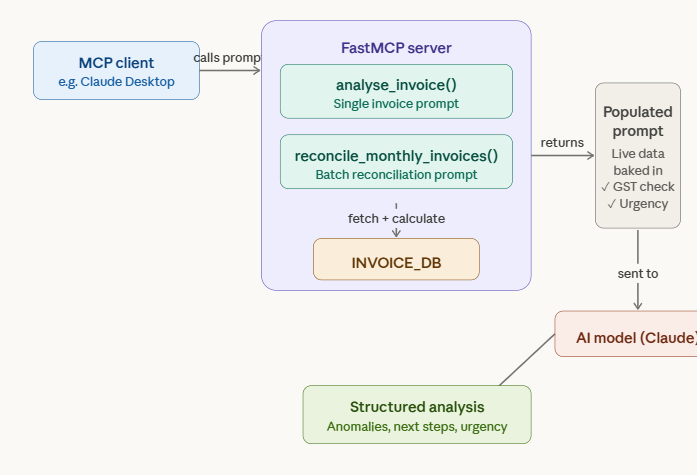

### What prompt reusability means here

Without `@mcp.prompt()`, every invoice analysis would require:
- Manually fetching data each time
- Recalculating due dates inline
- Re-writing the full prompt structure
- Risk of inconsistency across callers

`@mcp.prompt()` turns each function into a **reusable prompt factory**.

| Concept | Without MCP prompts | With `@mcp.prompt()` |
|---|---|---|
| Data fetching | Manual, every call | Encapsulated in the function |
| Urgency calc | Repeated logic | Computed once inside the prompt |
| Prompt structure | Copy-pasted strings | Single source of truth |
| Discoverability | None | Clients can list + invoke by name |
| Consistency | Fragile | Guaranteed same structure every time |

### Key advantages

1. **Consistency** — every call produces identically structured prompts; model output is predictable
2. **Separation of concerns** — *what to analyse* (prompt logic) is separate from *which data* (parameters)
3. **Live data injection** — `days_until` and `urgency` are pre-computed before the model sees the prompt
4. **Composability** — `reconcile_monthly_invoices` reuses the same pattern for batch use cases
5. **Discoverability** — MCP clients can list available prompts, see parameters/docstrings, and invoke without knowing DB internals

### One-line summary

> MCP + `@mcp.prompt()` lets you treat prompts like **API endpoints** — parameterised, data-aware functions any client can call, rather than raw strings you manually maintain.

---
## 4.4 🔄 Sampling — Servers Request LLM Completions

### 📖 CONCEPT

**Sampling** is the most advanced and unique MCP primitive. It **reverses the normal communication flow** — instead of the client calling the server, the **server sends a request back to the client**, asking it to invoke the LLM and return the result.

```
Normal flow:    Client  ──tools/call──▶  Server
Sampling flow:  Client  ◀──sampling/createMessage──  Server
```

### Why Sampling Exists:
- Allows servers to use AI intelligence **without hosting their own LLM**
- The **client retains control** over model selection, privacy, and cost
- Enables complex **agentic workflows** where tools can reason mid-execution
- Keeps **user conversation history private** — the server only sees what it sends

### ⚠️ Security Warning (2025):
> Security researchers identified sampling as a potential attack vector. A **malicious MCP server** could craft sampling requests to manipulate the LLM or extract sensitive data. Hosts **must** enforce consent and sandbox all sampling requests.

In [44]:
# 📖 CONCEPT: Sampling — Server-Initiated LLM Calls
# The code below shows the PATTERN — sampling requires a real LLM client to execute

from fastmcp import FastMCP, Context

mcp = FastMCP("Sampling Demo Server")

# ── Example 1: Tool that uses sampling to classify invoice type ───────────
SAMPLING_SERVER_CODE = '''
from fastmcp import FastMCP, Context
from mcp.server.session import ServerSession
from mcp.types import SamplingMessage, TextContent

mcp = FastMCP("Invoice Classifier")

@mcp.tool()
async def classify_invoice(
    invoice_text: str,
    ctx: Context            # ← Context gives access to sampling API
) -> dict:
    """
    Use the client LLM to intelligently classify an invoice.
    Categories: GOODS, SERVICES, MIXED, SUBSCRIPTION, MAINTENANCE
    """
    
    # Server sends a sampling request BACK to the client LLM
    # The server never sees the user\'s full conversation!
    result = await ctx.session.create_message(
        messages=[
            SamplingMessage(
                role="user",
                content=TextContent(
                    type="text",
                    text=f"""Classify this invoice into ONE category.
Categories: GOODS, SERVICES, MIXED, SUBSCRIPTION, MAINTENANCE
Respond with only the category name.

Invoice text:
{invoice_text}"""
                )
            )
        ],
        max_tokens=20,              # ← Keep it short — just need the category
        model_preferences={
            "hints": [{"name": "claude-haiku"}]  # ← Fast + cheap for classification
        }
    )
    
    category = result.content.text.strip().upper()
    
    return {
        "invoice_text_length": len(invoice_text),
        "category":            category,
        "classified_by":       "client_llm_via_sampling",  # ← Not the server\'s LLM!
        "model_used":          result.model
    }
'''

print("📋 Server-side code (uses sampling to call back to client LLM):")
print(SAMPLING_SERVER_CODE)

# ── Client-side sampling handler ──────────────────────────────────────────
SAMPLING_CLIENT_CODE = '''
# Client must provide a sampling_handler to support this
from fastmcp import Client
from fastmcp.client.sampling import RequestContext, SamplingMessage, SamplingParams

async def my_sampling_handler(
    messages: list[SamplingMessage],
    params:   SamplingParams,
    ctx:      RequestContext
) -> str:
    """Client handles sampling requests from any connected server."""
    # The client uses its own LLM (Anthropic, OpenAI, etc.)
    # to fulfil the server\'s sampling request
    prompt = messages[0].content.text
    
    # Call your LLM here (Anthropic, OpenAI, local model, etc.)
    response = await my_llm_client.complete(prompt, max_tokens=params.maxTokens)
    return response.text


# Connect with sampling support
async with Client("http://localhost:8000/mcp",
                  sampling_handler=my_sampling_handler) as client:
    result = await client.call_tool(
        "classify_invoice",
        {"invoice_text": "Laptop Charger x10, USB Cable x25"}
    )
    print(result)  # → {"category": "GOODS", ...}
'''

print("\n" + "=" * 60)
print("📋 Client-side code (handles the sampling callback):")
print("=" * 60)
print(SAMPLING_CLIENT_CODE)

📋 Server-side code (uses sampling to call back to client LLM):

from fastmcp import FastMCP, Context
from mcp.server.session import ServerSession
from mcp.types import SamplingMessage, TextContent

mcp = FastMCP("Invoice Classifier")

@mcp.tool()
async def classify_invoice(
    invoice_text: str,
    ctx: Context            # ← Context gives access to sampling API
) -> dict:
    """
    Use the client LLM to intelligently classify an invoice.
    Categories: GOODS, SERVICES, MIXED, SUBSCRIPTION, MAINTENANCE
    """
    
    # Server sends a sampling request BACK to the client LLM
    # The server never sees the user's full conversation!
    result = await ctx.session.create_message(
        messages=[
            SamplingMessage(
                role="user",
                content=TextContent(
                    type="text",
                    text=f"""Classify this invoice into ONE category.
Categories: GOODS, SERVICES, MIXED, SUBSCRIPTION, MAINTENANCE
Respond with only the categor

In [48]:
# 🖥️ RUN: Simulate sampling flow without a real LLM connection
# Jupyter-friendly version

from typing import NamedTuple

# ── Mock LLM for simulation ────────────────────────────────────────────────
class MockLLMResponse(NamedTuple):
    text: str
    model: str = "mock-claude-haiku"

async def mock_llm_classify(prompt: str) -> MockLLMResponse:
    """Simulates what the client LLM would return for a classification request."""
    prompt_lower = prompt.lower()
    if any(w in prompt_lower for w in ['laptop', 'cable', 'charger', 'hardware', 'equipment']):
        return MockLLMResponse("GOODS")
    elif any(w in prompt_lower for w in ['consulting', 'service', 'support', 'maintenance']):
        return MockLLMResponse("SERVICES")
    elif any(w in prompt_lower for w in ['subscription', 'monthly', 'annual', 'saas']):
        return MockLLMResponse("SUBSCRIPTION")
    return MockLLMResponse("MIXED")


# ── Simulate the full sampling flow ───────────────────────────────────────
async def simulate_sampling_flow(invoice_text: str):
    print(f"Step 1: Client calls tool 'classify_invoice'")
    print(f"        Invoice: '{invoice_text[:50]}...'")
    
    print(f"\nStep 2: Server receives tool call, needs LLM intelligence")
    print(f"        Server sends sampling/createMessage BACK to client")
    
    sampling_prompt = f"""\
Classify this invoice into ONE category.
Categories: GOODS, SERVICES, MIXED, SUBSCRIPTION, MAINTENANCE
Respond with only the category name.

Invoice text:
{invoice_text}"""
    
    print(f"\nStep 3: Client receives sampling request")
    print(f"        [Host shows consent: 'Allow server to call Claude?']")
    print(f"        Client invokes its LLM with the server's prompt")
    
    llm_response = await mock_llm_classify(sampling_prompt)
    
    print(f"\nStep 4: LLM responds → Client returns result to Server")
    print(f"        LLM output: '{llm_response.text}' (model: {llm_response.model})")
    
    print(f"\nStep 5: Server uses LLM result to complete tool execution")
    final_result = {
        "category": llm_response.text,
        "classified_by": "client_llm_via_sampling",
        "model_used": llm_response.model,
        "note": "Server never saw the user's conversation history!"
    }
    
    print(f"\nStep 6: Final tool result returned to client:")
    print(f"        {final_result}")
    return final_result


# ── Run simulation in Jupyter ─────────────────────────────────────────────
test_invoices = [
    "Laptop Charger x10 @ INR 1200, USB Cable x25 @ INR 150",
    "Cloud SaaS subscription - annual enterprise license",
    "Software development consulting - 40 hours @ INR 3000/hr"
]

for invoice in test_invoices:
    print("\n" + "=" * 60)
    result = await simulate_sampling_flow(invoice)
    print(f"\n→ CLASSIFICATION: {result['category']}")


Step 1: Client calls tool 'classify_invoice'
        Invoice: 'Laptop Charger x10 @ INR 1200, USB Cable x25 @ INR...'

Step 2: Server receives tool call, needs LLM intelligence
        Server sends sampling/createMessage BACK to client

Step 3: Client receives sampling request
        [Host shows consent: 'Allow server to call Claude?']
        Client invokes its LLM with the server's prompt

Step 4: LLM responds → Client returns result to Server
        LLM output: 'GOODS' (model: mock-claude-haiku)

Step 5: Server uses LLM result to complete tool execution

Step 6: Final tool result returned to client:
        {'category': 'GOODS', 'classified_by': 'client_llm_via_sampling', 'model_used': 'mock-claude-haiku', 'note': "Server never saw the user's conversation history!"}

→ CLASSIFICATION: GOODS

Step 1: Client calls tool 'classify_invoice'
        Invoice: 'Cloud SaaS subscription - annual enterprise licens...'

Step 2: Server receives tool call, needs LLM intelligence
        Server

---
# 5. Context Window Management in MCP

## 📖 CONCEPT: Why Context Management Matters

The context window is the most **finite and expensive** resource in any LLM workflow. Without careful management:

| Problem | Without MCP | With MCP |
|---------|-------------|----------|
| 50+ tool definitions | 20,000+ tokens per request | Loaded on-demand |
| Large tool outputs | Full dump into context | Structured via output schemas |
| Large documents | Pre-loaded every request | Fetched as needed via Resources |
| User input ambiguity | LLM guesses → wastes turns | Elicitation → structured UI input |

## 📖 CONCEPT: 5 Strategies MCP Uses

```
1. On-Demand Discovery  → Tool schemas loaded only when needed
2. Output Schemas       → Return only fields the LLM needs (spec 2025-06-18)
3. Resource Chunking    → Load only the section that's relevant
4. Roots Scoping        → Limit file access to declared directories
5. Elicitation          → Get structured user input before the LLM even tries
```

In [50]:
# 🖥️ RUN: Context Management Best Practices

# ── Strategy 1: Concise, precise tool descriptions ────────────────────────
# Bad: verbose description wastes tokens on every discovery
BAD_DESCRIPTION = """
This tool is designed to extract invoice data from emails that are received
in various formats including plain text, HTML, and structured data. It can
handle multiple invoice types and supports various currencies. The tool uses
advanced parsing algorithms to identify key invoice fields such as invoice
number, date, vendor information, line items, subtotals, taxes, and totals.
Please provide the full email body as input.
"""

# Good: under 100 words, focuses on WHAT not HOW
GOOD_DESCRIPTION = """Extract structured invoice data from a raw email body.
Returns invoice number, vendor, line items, totals, GST, and due date."""

print("=" * 60)
print("Strategy 1: Tool Description Length")
print("=" * 60)
print(f"❌ Bad  — {len(BAD_DESCRIPTION.split())} words, {len(BAD_DESCRIPTION)} chars")
print(f"✅ Good — {len(GOOD_DESCRIPTION.split())} words, {len(GOOD_DESCRIPTION)} chars")
print(f"   Savings: ~{len(BAD_DESCRIPTION) - len(GOOD_DESCRIPTION)} characters per tool discovery")

# ── Strategy 2: Return minimal fields from tools ──────────────────────────
# Imagine a tool that queries a database — two return strategies:

full_invoice_record = {
    "id": 1001, "invoice_number": "INV-1001", "vendor_name": "Alpha Electronics",
    "vendor_gstin": "27AAPFU0939F1ZV", "vendor_address": "123 MG Road, Pune",
    "vendor_phone": "+91-20-12345678", "vendor_email": "billing@alpha.com",
    "invoice_date": "2026-03-05", "due_date": "2026-03-20",
    "subtotal": 15750, "gst_rate": 18, "gst_amount": 2835, "total": 18585,
    "currency": "INR", "status": "pending", "payment_terms": "Net 15",
    "po_number": "PO-2026-089", "created_at": "2026-03-05T09:00:00Z",
    "updated_at": "2026-03-05T09:00:00Z", "approved_by": None,
    "payment_date": None, "notes": "", "tags": ["electronics", "hardware"]
}

# Minimal return — only what the LLM needs for typical tasks
minimal_invoice_return = {
    "invoice_number": "INV-1001",
    "vendor_name":    "Alpha Electronics",
    "total":          18585,
    "currency":       "INR",
    "due_date":       "2026-03-20",
    "status":         "pending"
}

print("\n" + "=" * 60)
print("Strategy 2: Return Minimal Fields (Output Schemas)")
print("=" * 60)
print(f"❌ Full record  — {len(str(full_invoice_record))} chars — contains noise LLM doesn't need")
print(f"✅ Minimal return — {len(str(minimal_invoice_return))} chars — only essential fields")
print(f"   Token savings: ~{len(str(full_invoice_record)) - len(str(minimal_invoice_return))} chars per tool call")

# ── Strategy 3: Resource chunking for large documents ─────────────────────
print("\n" + "=" * 60)
print("Strategy 3: Resource Chunking")
print("=" * 60)

chunked_resources = [
    "database://invoices/INV-1001?fields=summary",    # Just summary fields
    "database://invoices/INV-1001?fields=line_items", # Just line items
    "database://invoices/INV-1001?fields=full",       # Everything (last resort)
]
print("Instead of one large resource URI, expose granular variants:")
for uri in chunked_resources:
    print(f"  📁 {uri}")

# ── Strategy 4: Roots scoping ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("Strategy 4: Roots — Scope File Access")
print("=" * 60)

roots_config = {
    "roots": [
        {"uri": "file:///home/user/invoices/2026", "name": "2026 Invoices"},
        {"uri": "file:///home/user/vendors",        "name": "Vendor Data"}
        # Agent CANNOT access /home/user/personal or /etc/
    ]
}
import json
print("Client declares roots — server restricts all resource access to these paths:")
print(json.dumps(roots_config, indent=2))
print("  ✅ Agent can access: /home/user/invoices/2026/**")
print("  ✅ Agent can access: /home/user/vendors/**")
print("  ❌ Agent CANNOT access: /home/user/personal/ or anywhere else")

Strategy 1: Tool Description Length
❌ Bad  — 65 words, 425 chars
✅ Good — 20 words, 125 chars
   Savings: ~300 characters per tool discovery

Strategy 2: Return Minimal Fields (Output Schemas)
❌ Full record  — 615 chars — contains noise LLM doesn't need
✅ Minimal return — 148 chars — only essential fields
   Token savings: ~467 chars per tool call

Strategy 3: Resource Chunking
Instead of one large resource URI, expose granular variants:
  📁 database://invoices/INV-1001?fields=summary
  📁 database://invoices/INV-1001?fields=line_items
  📁 database://invoices/INV-1001?fields=full

Strategy 4: Roots — Scope File Access
Client declares roots — server restricts all resource access to these paths:
{
  "roots": [
    {
      "uri": "file:///home/user/invoices/2026",
      "name": "2026 Invoices"
    },
    {
      "uri": "file:///home/user/vendors",
      "name": "Vendor Data"
    }
  ]
}
  ✅ Agent can access: /home/user/invoices/2026/**
  ✅ Agent can access: /home/user/vendors/**
  ❌ Agent 

In [52]:
# 🖥️ RUN: Measuring context impact of tool loading strategies

import json

# Simulate what happens when loading many tools into context

def estimate_tokens(text: str) -> int:
    """Rough token estimate: ~4 chars per token"""
    return len(text) // 4

# 20 tool schemas (realistic enterprise MCP server)
tool_schemas = [
    {
        "name": f"tool_{i}",
        "description": f"This tool performs operation {i} on invoice data. It accepts various parameters.",
        "inputSchema": {
            "type": "object",
            "properties": {
                "invoice_id": {"type": "string", "description": "Invoice identifier"},
                "param_a":    {"type": "string", "description": f"Parameter A for operation {i}"},
                "param_b":    {"type": "integer", "description": f"Parameter B for operation {i}"},
            },
            "required": ["invoice_id"]
        }
    }
    for i in range(1, 21)
]

# Scenario A: Load ALL 20 tool schemas in every request (old function-calling style)
all_tools_json = json.dumps(tool_schemas)
all_tools_tokens = estimate_tokens(all_tools_json)

# Scenario B: MCP on-demand — only load 3 relevant tools for current task
relevant_tools = tool_schemas[:3]
relevant_tools_json = json.dumps(relevant_tools)
relevant_tokens = estimate_tokens(relevant_tools_json)

# Typical context window sizes
context_sizes = {
    "GPT-4o":          128_000,
    "Claude Sonnet":   200_000,
    "GPT-4o-mini":      16_000,
}

print("=" * 60)
print("Context Window Impact: All Tools vs On-Demand Loading")
print("=" * 60)
print(f"\n20 tools loaded (all):      ~{all_tools_tokens:,} tokens")
print(f"3 tools loaded (on-demand): ~{relevant_tokens:,} tokens")
print(f"Savings per request:        ~{all_tools_tokens - relevant_tokens:,} tokens")

print("\n--- Context % consumed by tools ---")
for model, ctx_size in context_sizes.items():
    pct_all      = (all_tools_tokens / ctx_size) * 100
    pct_relevant = (relevant_tokens  / ctx_size) * 100
    print(f"\n{model} ({ctx_size:,} tokens):")
    print(f"  All 20 tools  : {pct_all:.1f}% of context used by tool schemas alone")
    print(f"  3 relevant    : {pct_relevant:.1f}% of context used by tool schemas")
    print(f"  Remaining for : {'conversation & data' if pct_all < 90 else '⚠️ very little left!'}")

print("\n💡 With 50+ tools, loading ALL schemas can exhaust small-context models")
print("   MCP's on-demand discovery is the architectural solution to this problem.")

Context Window Impact: All Tools vs On-Demand Loading

20 tools loaded (all):      ~2,121 tokens
3 tools loaded (on-demand): ~316 tokens
Savings per request:        ~1,805 tokens

--- Context % consumed by tools ---

GPT-4o (128,000 tokens):
  All 20 tools  : 1.7% of context used by tool schemas alone
  3 relevant    : 0.2% of context used by tool schemas
  Remaining for : conversation & data

Claude Sonnet (200,000 tokens):
  All 20 tools  : 1.1% of context used by tool schemas alone
  3 relevant    : 0.2% of context used by tool schemas
  Remaining for : conversation & data

GPT-4o-mini (16,000 tokens):
  All 20 tools  : 13.3% of context used by tool schemas alone
  3 relevant    : 2.0% of context used by tool schemas
  Remaining for : conversation & data

💡 With 50+ tools, loading ALL schemas can exhaust small-context models
   MCP's on-demand discovery is the architectural solution to this problem.


---
# 6. Putting It All Together — Complete Invoice MCP Server

This final section combines **all 4 primitives** in a single, complete, runnable MCP server.

The server implements:
- 🛠️ **3 Tools** — extract, validate, update invoice
- 📁 **2 Resources** — config + invoice records
- 📝 **1 Prompt** — structured analysis template
- 🔄 **Sampling** — AI-powered invoice classification

In [54]:
# 🖥️ RUN: Complete Invoice MCP Server — All 4 Primitives

from fastmcp import FastMCP, Context
from datetime import datetime, date
from typing import Optional
import json, re, asyncio

# ══════════════════════════════════════════════════════════
#  INVOICE MCP SERVER
#  Demonstrates: Tools + Resources + Prompts + Sampling
# ══════════════════════════════════════════════════════════

mcp = FastMCP(
    name="Invoice Processor",
    instructions="Processes, validates, and analyses invoice data from emails."
)

# ── In-memory database ─────────────────────────────────────────────────────
DB: dict = {}


# ══════════════════════════════════════════════════════════
#  TOOLS  (model-controlled)
# ══════════════════════════════════════════════════════════

@mcp.tool()
def extract_and_store_invoice(email_body: str, currency: str = "INR") -> dict:
    """Extract invoice data from email and persist to database."""
    inv_no = re.search(r'Invoice Number\s*[:\-]\s*(\S+)', email_body, re.I)
    vendor  = re.search(r'Vendor Name\s*[:\-]\s*(.+)',   email_body, re.I)
    total   = re.search(r'Total Invoice Amount\s*[:\-]\s*([\d,]+)', email_body, re.I)
    sub     = re.search(r'Subtotal\s*[:\-]\s*([\d,]+)',  email_body, re.I)
    gst     = re.search(r'GST.*?[:\-]\s*([\d,]+)',       email_body, re.I)
    due     = re.search(r'Payment Due Date\s*[:\-]\s*(\S+)', email_body, re.I)

    if not inv_no:
        return {"success": False, "error": "Invoice number not found"}

    record = {
        "invoice_number": inv_no.group(1),
        "vendor_name":    vendor.group(1).strip() if vendor else "Unknown",
        "subtotal":       float(sub.group(1).replace(',','')) if sub else 0,
        "gst_amount":     float(gst.group(1).replace(',','')) if gst else 0,
        "total":          float(total.group(1).replace(',','')) if total else 0,
        "currency":       currency,
        "due_date":       due.group(1) if due else None,
        "status":         "pending",
        "extracted_at":   datetime.now().isoformat()
    }
    DB[record["invoice_number"]] = record
    return {"success": True, "invoice": record}


@mcp.tool()
def validate_invoice(invoice_number: str) -> dict:
    """Validate invoice maths: verify subtotal + GST = total."""
    if invoice_number not in DB:
        return {"valid": False, "error": f"{invoice_number} not in database"}
    inv      = DB[invoice_number]
    expected = round(inv["subtotal"] + inv["gst_amount"], 2)
    diff     = round(expected - inv["total"], 2)
    return {
        "invoice_number": invoice_number,
        "valid":          abs(diff) < 0.01,
        "subtotal":       inv["subtotal"],
        "gst_amount":     inv["gst_amount"],
        "expected_total": expected,
        "stated_total":   inv["total"],
        "discrepancy":    diff
    }


@mcp.tool()
def mark_invoice_paid(invoice_number: str, payment_reference: Optional[str] = None) -> dict:
    """Mark an invoice as paid and record payment reference."""
    if invoice_number not in DB:
        return {"success": False, "error": f"{invoice_number} not found"}
    DB[invoice_number]["status"]    = "paid"
    DB[invoice_number]["paid_at"]   = datetime.now().isoformat()
    DB[invoice_number]["payment_ref"] = payment_reference
    return {"success": True, "invoice_number": invoice_number, "status": "paid"}


# ══════════════════════════════════════════════════════════
#  RESOURCES  (application-controlled)
# ══════════════════════════════════════════════════════════

@mcp.resource("config://invoice-processor/info",
              description="Server capabilities and configuration")
def server_config() -> dict:
    return {"name": "Invoice Processor", "version": "1.0.0",
            "currencies": ["INR","USD","EUR"], "spec": "2025-06-18"}


@mcp.resource("database://invoices/{invoice_id}",
              description="Retrieve a stored invoice by ID")
def get_invoice_resource(invoice_id: str) -> dict:
    return DB.get(invoice_id, {"error": f"{invoice_id} not found",
                               "available": list(DB.keys())})


# ══════════════════════════════════════════════════════════
#  PROMPTS  (user-controlled)
# ══════════════════════════════════════════════════════════

@mcp.prompt()
def review_invoice(invoice_number: str) -> str:
    """
    Generate a complete invoice review prompt.
    
    Args:
        invoice_number: Invoice ID to review (e.g. INV-1001)
    """
    inv = DB.get(invoice_number)
    if not inv:
        return f"Invoice {invoice_number} not found. Available: {list(DB.keys())}"

    # Embed live data from database into the prompt
    return f"""You are an accounts-payable specialist. Review this invoice:

Invoice : {inv['invoice_number']}
Vendor  : {inv['vendor_name']}
Total   : {inv['currency']} {inv['total']:,.0f}
Due     : {inv.get('due_date', 'N/A')}
Status  : {inv['status'].upper()}

Provide:
1. Mathematical verification of totals
2. Payment urgency assessment
3. Recommended action"""


# ══════════════════════════════════════════════════════════
#  DEMO — run all primitives in sequence
# ══════════════════════════════════════════════════════════

SAMPLE_EMAIL = """
Invoice Details
---------------
Invoice Number : INV-2001
Invoice Date   : 05-Mar-2026
Vendor Name    : Alpha Electronics Pvt Ltd

Subtotal                  : 15750
GST (18%)                 : 2835
Total Invoice Amount      : 18585

Payment Due Date          : 20-Mar-2026
"""

print("=" * 60)
print("🛠️  TOOL 1: extract_and_store_invoice")
print("=" * 60)
r1 = extract_and_store_invoice(SAMPLE_EMAIL)
print(json.dumps(r1, indent=2, default=str))

print("\n" + "=" * 60)
print("🛠️  TOOL 2: validate_invoice")
print("=" * 60)
r2 = validate_invoice("INV-2001")
print(json.dumps(r2, indent=2))
print("✅ Valid" if r2["valid"] else "❌ Invalid")

print("\n" + "=" * 60)
print("📁  RESOURCE: database://invoices/INV-2001")
print("=" * 60)
print(json.dumps(get_invoice_resource("INV-2001"), indent=2, default=str))

print("\n" + "=" * 60)
print("📝  PROMPT: review_invoice('INV-2001')")
print("=" * 60)
print(review_invoice("INV-2001"))

print("\n" + "=" * 60)
print("🛠️  TOOL 3: mark_invoice_paid")
print("=" * 60)
r3 = mark_invoice_paid("INV-2001", payment_reference="NEFT-20260310-XYZ")
print(json.dumps(r3, indent=2))

print("\n" + "=" * 60)
print("✅ ALL PRIMITIVES DEMONSTRATED SUCCESSFULLY")
print("=" * 60)
print(f"\n  🛠️  Tools registered    : extract_and_store_invoice, validate_invoice, mark_invoice_paid")
print(f"  📁  Resources registered : config://invoice-processor/info, database://invoices/{{id}}")
print(f"  📝  Prompts registered   : review_invoice")
print(f"  🔄  Sampling             : use ctx.session.create_message() inside any tool")
print(f"\nTo run as a real MCP server:")
print(f"  mcp.run(transport='stdio')              # for Claude Desktop / Cursor")
print(f"  mcp.run(transport='streamable-http')    # for remote / cloud deployment")

🛠️  TOOL 1: extract_and_store_invoice
{
  "success": true,
  "invoice": {
    "invoice_number": "INV-2001",
    "vendor_name": "Alpha Electronics Pvt Ltd",
    "subtotal": 15750.0,
    "gst_amount": 2835.0,
    "total": 18585.0,
    "currency": "INR",
    "due_date": "20-Mar-2026",
    "status": "pending",
    "extracted_at": "2026-03-11T00:30:19.512605"
  }
}

🛠️  TOOL 2: validate_invoice
{
  "invoice_number": "INV-2001",
  "valid": true,
  "subtotal": 15750.0,
  "gst_amount": 2835.0,
  "expected_total": 18585.0,
  "stated_total": 18585.0,
  "discrepancy": 0.0
}
✅ Valid

📁  RESOURCE: database://invoices/INV-2001
{
  "invoice_number": "INV-2001",
  "vendor_name": "Alpha Electronics Pvt Ltd",
  "subtotal": 15750.0,
  "gst_amount": 2835.0,
  "total": 18585.0,
  "currency": "INR",
  "due_date": "20-Mar-2026",
  "status": "pending",
  "extracted_at": "2026-03-11T00:30:19.512605"
}

📝  PROMPT: review_invoice('INV-2001')
You are an accounts-payable specialist. Review this invoice:

Invoice :

---
# 📋 Module 2 — Summary

| Topic | Key Takeaway |
|-------|--------------|
| **Architecture** | 3 layers: Host (LLM + orchestrator) → Client (1:1 per server) → Server (capabilities). Servers are isolated. |
| **Communication** | JSON-RPC 2.0. 4 phases: Initialize → Discover → Operate → Terminate. Bidirectional. |
| **stdio** | Local transport. Zero config. `mcp.run(transport='stdio')`. Best for Claude Desktop, Cursor, dev tools. |
| **Streamable HTTP** | Remote transport. `mcp.run(transport='streamable-http')`. OAuth 2.1 ready. Old SSE deprecated Mar 2025. |
| **Tools** | `@mcp.tool()` — model-controlled. FastMCP auto-generates JSON Schema from type hints + docstring. |
| **Resources** | `@mcp.resource(uri)` — application-controlled. URI-based. Support subscriptions. |
| **Prompts** | `@mcp.prompt()` — user-controlled. Appear as slash commands. Embed live data. |
| **Sampling** | `ctx.session.create_message()` — server calls back to client LLM. Client retains control. |
| **Context Mgmt** | Short descriptions + minimal returns + resource chunking + roots + elicitation = efficient context. |

---

## 🚀 What's Next — Module 3

- Setting up your local MCP development environment (uv, MCP Inspector)
- Building and testing your first real MCP server from scratch
- Connecting it to Claude Desktop
- Debugging with the MCP Inspector tool

---
*GenAI Course — Module 2 | MCP Spec 2025-06-18 | Compiled March 2026*